## **Preprocessing Suara Buka Tutup**


### ***1. Import & Setup***

In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from sklearn.model_selection import train_test_split

TRAIN_DIR = "dataset48k/train"

# Parameter preprocessing
TARGET_SR = 22050         # target sample rate
TARGET_DURATION = 1.0     # target durasi 1 detik
MAX_LEN = int(TARGET_SR * TARGET_DURATION)
TEST_SIZE = 0.2          # 20% untuk validasi, 80% untuk training
RANDOM_STATE = 42        # untuk reproducibility

### ***2. Fungsi Preprocessing Audio***

- Konversi sample rate ke TARGET_SR
- Pangkas / tambal (pad) durasi jadi 1 detik
- normalisasi amplitudo
- peredaman noise sederhana (menghapus amplitudo kecil)

In [2]:
def preprocess_audio(file_path, target_sr=TARGET_SR, target_len=MAX_LEN, noise_reduction=True):
    """
    Membaca audio dan mengubah ke bentuk konsisten (sample rate, durasi, normalisasi)
    """
    # 1. Load audio
    y, sr = librosa.load(file_path, sr=target_sr)
    
    # 2. Trim ke durasi tetap (potong / pad)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')
    else:
        y = y[:target_len]
    
    # 3. Normalisasi amplitudo (skala -1 sampai 1)
    y = y / np.max(np.abs(y) + 1e-6)
    
    # 4. Hilangkan noise kecil
    if noise_reduction:
        y[np.abs(y) < 0.005] = 0.0
    
    return y, sr


### ***3. Contoh sebelum dan sesudah preprocessing***

Sample rate asli: 48000 Hz | Durasi asli: 2.56s
Sample rate baru: 22050 Hz | Durasi baru: 1.00s


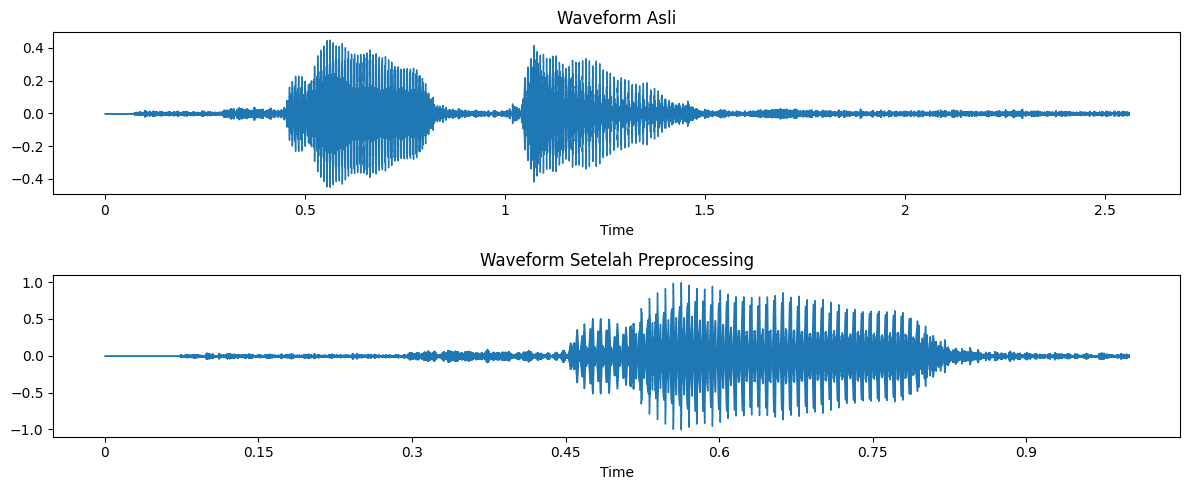

🔊 Sebelum preprocessing:


🔊 Setelah preprocessing:


In [3]:
sample_file = os.path.join(TRAIN_DIR, "buka", os.listdir(os.path.join(TRAIN_DIR, "buka"))[10])

y_raw, sr_raw = librosa.load(sample_file, sr=None)
y_proc, sr_proc = preprocess_audio(sample_file)

print(f"Sample rate asli: {sr_raw} Hz | Durasi asli: {len(y_raw)/sr_raw:.2f}s")
print(f"Sample rate baru: {sr_proc} Hz | Durasi baru: {len(y_proc)/sr_proc:.2f}s")

fig, ax = plt.subplots(2, 1, figsize=(12, 5))
librosa.display.waveshow(y_raw, sr=sr_raw, ax=ax[0])
ax[0].set_title("Waveform Asli")
librosa.display.waveshow(y_proc, sr=sr_proc, ax=ax[1])
ax[1].set_title("Waveform Setelah Preprocessing")
plt.tight_layout()
plt.show()

print("🔊 Sebelum preprocessing:")
ipd.display(ipd.Audio(y_raw, rate=sr_raw))
print("🔊 Setelah preprocessing:")
ipd.display(ipd.Audio(y_proc, rate=sr_proc))


### ***4. Buat dataset hasil preprocessing***

Langkah ini akan membaca semua file audio, preprocessing semuanya, dan menyimpannya dalam bentuk list siap ekstraksi fitur.

In [4]:
import tqdm
import joblib

def preprocess_dataset_with_split(base_path, test_size=0.2, random_state=42):
    """
    Membaca seluruh file audio, preprocessing, dan split menjadi train/val
    """
    all_data = []
    for label in os.listdir(base_path):
        folder = os.path.join(base_path, label)
        if not os.path.isdir(folder):
            continue
        
        files = os.listdir(folder)
        print(f"Processing {len(files)} files from {label} class...")
        
        for fn in tqdm.tqdm(files, desc=f"Processing {label}"):
            file_path = os.path.join(folder, fn)
            y, sr = preprocess_audio(file_path)
            all_data.append((y, label, fn))
    
    # Split data
    X = [(y, fn) for y, label, fn in all_data]  
    y = [label for y, label, fn in all_data]    
    
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state, 
        stratify=y
    )
    
    train_data = [(x[0], label) for x, label in zip(X_train, y_train)]
    val_data = [(x[0], label) for x, label in zip(X_val, y_val)]
    
    return train_data, val_data

train_data, val_data = preprocess_dataset_with_split(TRAIN_DIR, TEST_SIZE, RANDOM_STATE)

joblib.dump(train_data, "train_preprocessed.pkl")
joblib.dump(val_data, "val_preprocessed.pkl")

print(f"✅ Data berhasil di-split:")
print(f"   Training: {len(train_data)} samples")
print(f"   Validation: {len(val_data)} samples")

# Cek distribusi kelas setelah split
from collections import Counter
train_labels = [label for _, label in train_data]
val_labels = [label for _, label in val_data]

print(f"\n📊 Distribusi kelas setelah split:")
print(f"Training - {dict(Counter(train_labels))}")
print(f"Validation - {dict(Counter(val_labels))}")

Processing 100 files from buka class...


Processing buka:   0%|                                                                                                                                      | 0/100 [00:00<?, ?it/s]

Processing buka:  18%|██████████████████████▎                                                                                                     | 18/100 [00:00<00:00, 176.56it/s]

Processing buka:  37%|█████████████████████████████████████████████▉                                                                              | 37/100 [00:00<00:00, 180.51it/s]

Processing buka:  56%|█████████████████████████████████████████████████████████████████████▍                                                      | 56/100 [00:00<00:00, 178.56it/s]

...

Processing tutup:  55%|███████████████████████████████████████████████████████████████████▋                                                       | 55/100 [00:00<00:00, 181.51it/s]

Processing tutup:  74%|███████████████████████████████████████████████████████████████████████████████████████████                                | 74/100 [00:00<00:00, 174.25it/s]

Processing tutup:  92%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏         | 92/100 [00:00<00:00, 160.38it/s]

Processing tutup: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 167.97it/s]

✅ Data berhasil di-split:
   Training: 160 samples
   Validation: 40 samples

📊 Distribusi kelas setelah split:
Training - {'buka': 80, 'tutup': 80}
Validation - {'buka': 20, 'tutup': 20}


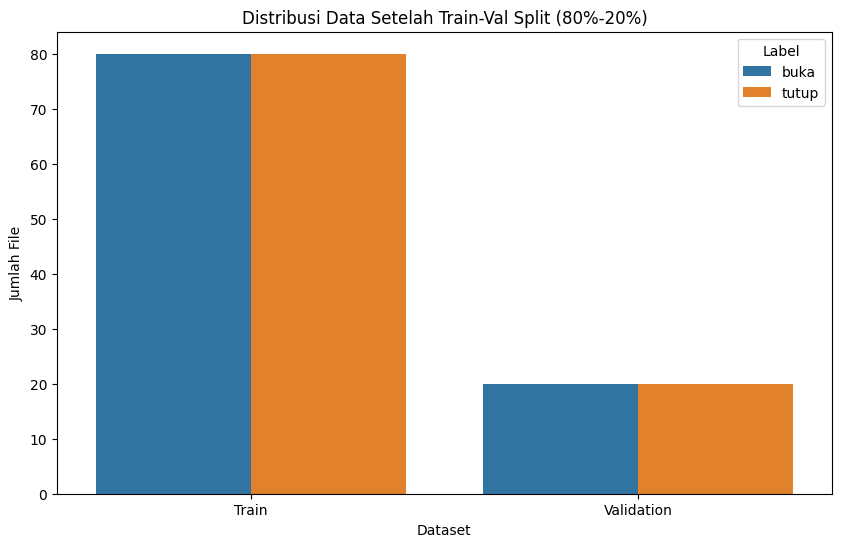


Proporsi split:
Training: 160/200 = 80.0%
Validation: 40/200 = 20.0%


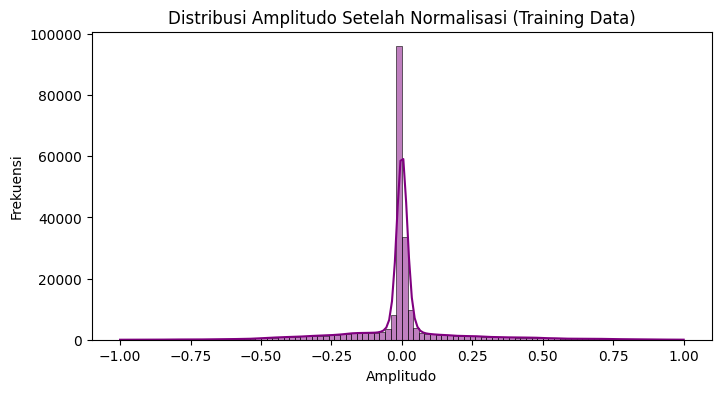

In [5]:
import seaborn as sns
from collections import Counter
import pandas as pd

# Buat dataframe untuk visualisasi
train_counter = Counter(train_labels)
val_counter = Counter(val_labels)

split_data = []
for label in train_counter.keys():
    split_data.append({'Dataset': 'Train', 'Label': label, 'Jumlah': train_counter[label]})
    split_data.append({'Dataset': 'Validation', 'Label': label, 'Jumlah': val_counter[label]})

df_split = pd.DataFrame(split_data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_split, x='Dataset', y='Jumlah', hue='Label')
plt.title("Distribusi Data Setelah Train-Val Split (80%-20%)")
plt.ylabel("Jumlah File")
plt.show()

print("\nProporsi split:")
total_train = sum(train_counter.values())
total_val = sum(val_counter.values())
total_all = total_train + total_val

print(f"Training: {total_train}/{total_all} = {total_train/total_all*100:.1f}%")
print(f"Validation: {total_val}/{total_all} = {total_val/total_all*100:.1f}%")

# Analisis distribusi amplitudo dari data training
samples = [y for y, _ in train_data[:10]]
amps = np.concatenate(samples)

plt.figure(figsize=(8,4))
sns.histplot(amps, bins=100, color='purple', kde=True)
plt.title("Distribusi Amplitudo Setelah Normalisasi (Training Data)")
plt.xlabel("Amplitudo")
plt.ylabel("Frekuensi")
plt.show()

## **Feature Extraction (Statistik Time Series) Suara Buka Tutup**

### ***1. Import & Load Data***

In [6]:
import numpy as np
import pandas as pd
import librosa
import scipy.stats
import joblib
import tqdm
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import json

train_data = joblib.load("train_preprocessed.pkl")
val_data   = joblib.load("val_preprocessed.pkl")

print(f"Data berhasil dimuat. Total train: {len(train_data)}, val: {len(val_data)}")


Data berhasil dimuat. Total train: 160, val: 40


### ***2. Fungsi Ekstraksi Fitur***

Fungsi ini akan menghitung berbagai statistik dasar dari setiap audio signal.

In [7]:
def extract_comprehensive_features(y, sr=22050):

    feats = {}
    
    # FITUR STATISTIK 
    feats['stat_mean'] = np.mean(y)
    feats['stat_std'] = np.std(y)
    feats['stat_var'] = np.var(y)
    feats['stat_skew'] = scipy.stats.skew(y)
    feats['stat_kurt'] = scipy.stats.kurtosis(y)
    feats['stat_min'] = np.min(y)
    feats['stat_max'] = np.max(y)
    feats['stat_range'] = np.max(y) - np.min(y)
    feats['stat_median'] = np.median(y)
    feats['stat_q25'] = np.percentile(y, 25)
    feats['stat_q75'] = np.percentile(y, 75)
    feats['stat_iqr'] = np.percentile(y, 75) - np.percentile(y, 25)

    # FITUR TEMPORAL
    feats['temp_rms'] = np.sqrt(np.mean(y**2))
    feats['temp_energy'] = np.sum(y**2)
    feats['temp_zcr'] = np.mean(librosa.feature.zero_crossing_rate(y))
    
    # Autocorrelation features
    autocorr = np.correlate(y, y, mode='full')
    autocorr = autocorr[autocorr.size // 2:]
    feats['temp_autocorr_max'] = np.max(autocorr[1:100]) if len(autocorr) > 100 else np.max(autocorr[1:])
    
    # Peak analysis
    peaks = librosa.util.peak_pick(np.abs(y), pre_max=3, post_max=3, pre_avg=3, post_avg=5, delta=0.1, wait=10)
    feats['temp_peak_count'] = len(peaks)
    feats['temp_peak_mean'] = np.mean(np.abs(y[peaks])) if len(peaks) > 0 else 0
    
    # Onset detection
    onset_frames = librosa.onset.onset_detect(y=y, sr=sr)
    feats['temp_onset_count'] = len(onset_frames)
    feats['temp_onset_rate'] = len(onset_frames) / (len(y) / sr)

    # FITUR SPEKTRAL
    # Basic spectral features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    feats['spec_centroid_mean'] = np.mean(centroid)
    feats['spec_centroid_std'] = np.std(centroid)
    
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    feats['spec_bandwidth_mean'] = np.mean(bandwidth)
    feats['spec_bandwidth_std'] = np.std(bandwidth)
    
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    feats['spec_rolloff_mean'] = np.mean(rolloff)
    feats['spec_rolloff_std'] = np.std(rolloff)
    
    flatness = librosa.feature.spectral_flatness(y=y)
    feats['spec_flatness_mean'] = np.mean(flatness)
    feats['spec_flatness_std'] = np.std(flatness)
    
    # Spectral contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    for i in range(contrast.shape[0]):
        feats[f'spec_contrast_{i}_mean'] = np.mean(contrast[i])
        feats[f'spec_contrast_{i}_std'] = np.std(contrast[i])
    
    # MFCCs (Mel-frequency cepstral coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(mfccs.shape[0]):
        feats[f'mfcc_{i}_mean'] = np.mean(mfccs[i])
        feats[f'mfcc_{i}_std'] = np.std(mfccs[i])
    
    # Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    for i in range(chroma.shape[0]):
        feats[f'chroma_{i}_mean'] = np.mean(chroma[i])
        feats[f'chroma_{i}_std'] = np.std(chroma[i])
    
    # Mel-scale spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=10)
    for i in range(mel_spec.shape[0]):
        feats[f'mel_{i}_mean'] = np.mean(mel_spec[i])
        feats[f'mel_{i}_std'] = np.std(mel_spec[i])
    
    # Tonnetz (harmonic network)
    tonnetz = librosa.feature.tonnetz(y=y, sr=sr)
    for i in range(tonnetz.shape[0]):
        feats[f'tonnetz_{i}_mean'] = np.mean(tonnetz[i])
        feats[f'tonnetz_{i}_std'] = np.std(tonnetz[i])
    
    # Spectral entropy
    stft = librosa.stft(y)
    magnitude = np.abs(stft)
    power_spec = magnitude ** 2
    normalized_power = power_spec / (np.sum(power_spec, axis=0, keepdims=True) + 1e-10)
    spectral_entropy = -np.sum(normalized_power * np.log2(normalized_power + 1e-10), axis=0)
    feats['spec_entropy_mean'] = np.mean(spectral_entropy)
    feats['spec_entropy_std'] = np.std(spectral_entropy)
    
    # Time-domain entropy
    hist, _ = np.histogram(y, bins=50, density=True)
    hist = hist[hist > 0]
    feats['stat_entropy'] = -np.sum(hist * np.log2(hist)) if len(hist) > 0 else 0
    
    return feats


### ***3. Bangun Dataset Fitur dari train & val***

looping seluruh audio hasil preprocessing dan ambil fiturnya.

In [8]:
def build_comprehensive_feature_dataset(preprocessed_data, sr=22050):

    feature_list = []
    for y, label in tqdm.tqdm(preprocessed_data, desc="Extracting comprehensive features"):
        f = extract_comprehensive_features(y, sr)
        f['label'] = label
        feature_list.append(f)
    return pd.DataFrame(feature_list)

print("Ekstraksi fitur komprehensif...")
train_features_full = build_comprehensive_feature_dataset(train_data)
val_features_full = build_comprehensive_feature_dataset(val_data)

print(f"Total fitur diekstraksi: {train_features_full.shape[1] - 1} fitur")
print("Contoh hasil ekstraksi fitur:")
display(train_features_full.head())

# Simpan dataset lengkap
train_features_full.to_csv("train_features_full.csv", index=False)
val_features_full.to_csv("val_features_full.csv", index=False)
print("File fitur lengkap disimpan: train_features_full.csv dan val_features_full.csv")


Ekstraksi fitur komprehensif...


Extracting comprehensive features:   0%|                                                                                                                    | 0/160 [00:00<?, ?it/s]

C:\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=690
  warnings.warn(
C:\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=345
  warnings.warn(
Extracting comprehensive features:   1%|▋                                                                                                           | 1/160 [00:00<01:37,  1.63it/s]

Extracting comprehensive features:   1%|█▎                                                                                                          | 2/160 [00:00<01:12,  2.18it/s]

Extracting comprehensive features:   2%|██                                                                                                          | 3/160 [00:01<01:06,  2.37it/s]

...

Extracting comprehensive features:  49%|████████████████████████████████████████████████████▊                                                      | 79/160 [00:29<00:31,  2.60it/s]

Extracting comprehensive features:  50%|█████████████████████████████████████████████████████▌                                                     | 80/160 [00:29<00:30,  2.64it/s]

Extracting comprehensive features:  51%|██████████████████████████████████████████████████████▏                                                    | 81/160 [00:29<00:30,  2.56it/s]

Extracting comprehensive features:  51%|██████████████████████████████████████████████████████▏                                                    | 81/160 [00:30<00:29,  2.70it/s]

KeyboardInterrupt: 

### ***4. Feature Importance Analysis & Selection***

Training Random Forest untuk analisis feature importance...

HASIL ANALISIS FEATURE IMPORTANCE
Total fitur awal: 127
Threshold: 50% dari importance maksimum
Absolute threshold: 0.040541
Fitur yang dipilih: 5
Fitur yang dihapus: 122


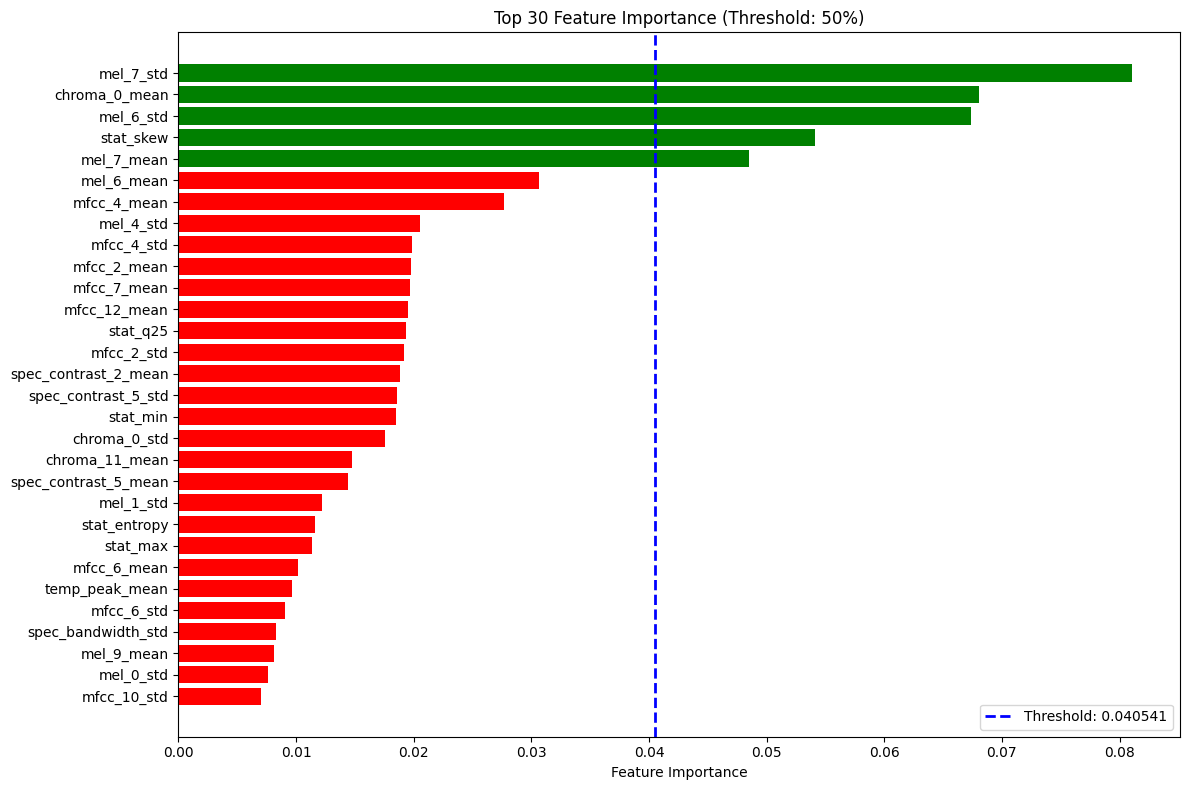


ANALISIS PER KATEGORI FITUR
   Category  Total_Features  Selected_Features  Selection_Rate  Avg_Importance
Statistical              13                  1          7.6923          0.0102
   Temporal               8                  0          0.0000          0.0028
   Spectral              24                  0          0.0000          0.0051
       MFCC              26                  0          0.0000          0.0081
     Chroma              24                  1          4.1667          0.0063
        Mel              20                  3         15.0000          0.0163
    Tonnetz              12                  0          0.0000          0.0028


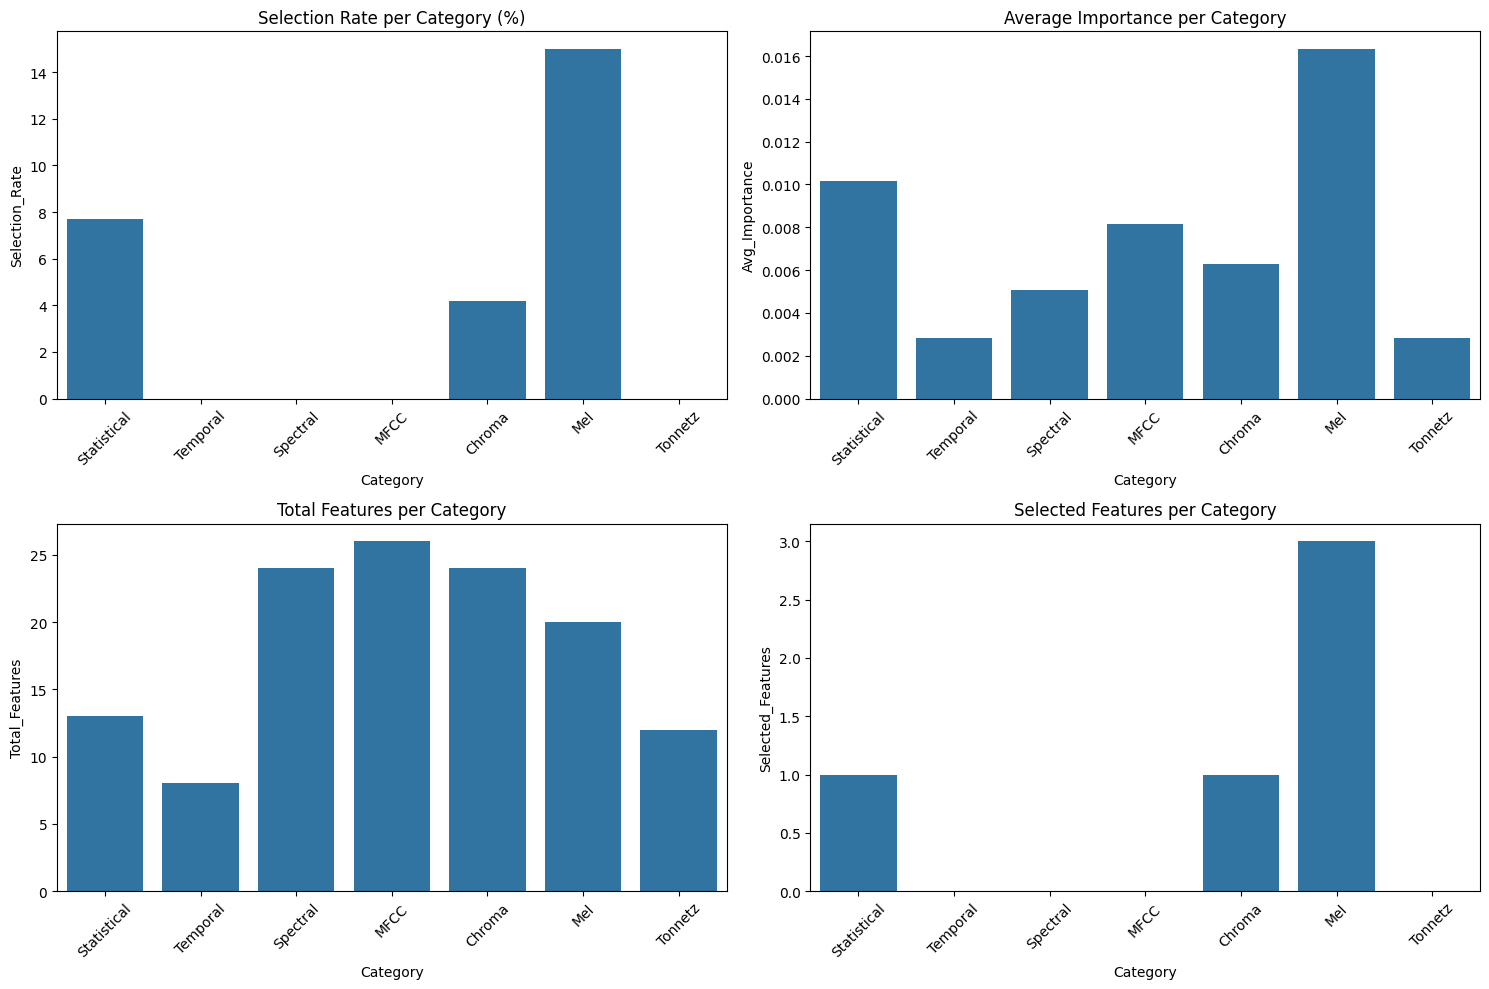


MENYIMPAN DATASET TERPILIH
Shape train terpilih: (160, 6)
Shape val terpilih: (40, 6)


In [48]:
def feature_importance_analysis(train_df, val_df, importance_threshold=50):

    # Pisahkan fitur dan label
    X_train = train_df.drop(columns=['label'])
    y_train = train_df['label']
    X_val = val_df.drop(columns=['label'])
    y_val = val_df['label']
    
    # Train Random Forest untuk mendapatkan feature importance
    print("Training Random Forest untuk analisis feature importance...")
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    
    # Dapatkan feature importance
    importances = pd.Series(rf_temp.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    
    # Hitung threshold berdasarkan persentase dari importance maksimum
    max_importance = importances.max()
    absolute_threshold = max_importance * (importance_threshold / 100)
    
    # Fitur yang lolos threshold
    selected_features = importances[importances >= absolute_threshold].index.tolist()
    removed_features = importances[importances < absolute_threshold].index.tolist()
    
    print(f"\nHASIL ANALISIS FEATURE IMPORTANCE")
    print(f"{'='*50}")
    print(f"Total fitur awal: {len(importances)}")
    print(f"Threshold: {importance_threshold}% dari importance maksimum")
    print(f"Absolute threshold: {absolute_threshold:.6f}")
    print(f"Fitur yang dipilih: {len(selected_features)}")
    print(f"Fitur yang dihapus: {len(removed_features)}")
    
    # Visualisasi feature importance
    plt.figure(figsize=(12, 8))
    
    colors = ['green' if imp >= absolute_threshold else 'red' for imp in importances.values]
    
    # Tampilkan top 30 fitur untuk readability
    top_features = importances.head(30)
    top_colors = colors[:30]
    
    plt.barh(range(len(top_features)), top_features.values, color=top_colors)
    plt.yticks(range(len(top_features)), top_features.index)
    plt.xlabel('Feature Importance')
    plt.title(f'Top 30 Feature Importance (Threshold: {importance_threshold}%)')
    plt.axvline(x=absolute_threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {absolute_threshold:.6f}')
    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Analisis per kategori fitur
    feature_categories = {
        'Statistical': [f for f in importances.index if f.startswith('stat_')],
        'Temporal': [f for f in importances.index if f.startswith('temp_')],
        'Spectral': [f for f in importances.index if f.startswith('spec_')],
        'MFCC': [f for f in importances.index if f.startswith('mfcc_')],
        'Chroma': [f for f in importances.index if f.startswith('chroma_')],
        'Mel': [f for f in importances.index if f.startswith('mel_')],
        'Tonnetz': [f for f in importances.index if f.startswith('tonnetz_')]
    }
    
    category_analysis = []
    for category, features in feature_categories.items():
        category_features = [f for f in features if f in importances.index]
        if category_features:
            selected_in_category = [f for f in category_features if f in selected_features]
            avg_importance = importances[category_features].mean()
            category_analysis.append({
                'Category': category,
                'Total_Features': len(category_features),
                'Selected_Features': len(selected_in_category),
                'Selection_Rate': len(selected_in_category) / len(category_features) * 100,
                'Avg_Importance': avg_importance
            })
    
    category_df = pd.DataFrame(category_analysis)
    
    print(f"\nANALISIS PER KATEGORI FITUR")
    print(f"{'='*50}")
    print(category_df.to_string(index=False, float_format='%.4f'))
    
    # Visualisasi per kategori
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Selection rate per category
    sns.barplot(data=category_df, x='Category', y='Selection_Rate', ax=axes[0,0])
    axes[0,0].set_title('Selection Rate per Category (%)')
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # Average importance per category
    sns.barplot(data=category_df, x='Category', y='Avg_Importance', ax=axes[0,1])
    axes[0,1].set_title('Average Importance per Category')
    axes[0,1].tick_params(axis='x', rotation=45)
    
    # Total features per category
    sns.barplot(data=category_df, x='Category', y='Total_Features', ax=axes[1,0])
    axes[1,0].set_title('Total Features per Category')
    axes[1,0].tick_params(axis='x', rotation=45)
    
    # Selected features per category
    sns.barplot(data=category_df, x='Category', y='Selected_Features', ax=axes[1,1])
    axes[1,1].set_title('Selected Features per Category')
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Buat dataset dengan fitur terpilih
    X_train_selected = X_train[selected_features]
    X_val_selected = X_val[selected_features]
    
    train_selected = X_train_selected.copy()
    train_selected['label'] = y_train
    
    val_selected = X_val_selected.copy()
    val_selected['label'] = y_val
    
    print(f"\nMENYIMPAN DATASET TERPILIH")
    print(f"{'='*50}")
    print(f"Shape train terpilih: {train_selected.shape}")
    print(f"Shape val terpilih: {val_selected.shape}")
    
    return train_selected, val_selected, selected_features, removed_features, importances

train_selected, val_selected, selected_features, removed_features, feature_importances = feature_importance_analysis(
    train_features_full, val_features_full, importance_threshold=50
)

train_selected.to_csv("train_features_selected.csv", index=False)
val_selected.to_csv("val_features_selected.csv", index=False)


### ***5. Detail Analysis***

In [49]:
def detailed_feature_analysis(selected_features, removed_features, feature_importances):
    """
    Analisis detail fitur yang dipilih dan yang dihapus
    """
    print(f"\nDETAIL FITUR TERPILIH")
    print(f"{'='*70}")
    print(f"{'Fitur':<30} {'Importance':<15} {'Kategori':<15}")
    print(f"{'-'*70}")
    
    for feature in selected_features:
        importance = feature_importances[feature]
        if feature.startswith('stat_'):
            category = 'Statistical'
        elif feature.startswith('temp_'):
            category = 'Temporal'
        elif feature.startswith('spec_'):
            category = 'Spectral'
        elif feature.startswith('mfcc_'):
            category = 'MFCC'
        elif feature.startswith('chroma_'):
            category = 'Chroma'
        elif feature.startswith('mel_'):
            category = 'Mel'
        elif feature.startswith('tonnetz_'):
            category = 'Tonnetz'
        else:
            category = 'Other'
        
        print(f"{feature:<30} {importance:<15.6f} {category:<15}")
    
    print(f"\nFITUR YANG DIHAPUS (Top 10)")
    print(f"{'='*70}")
    print(f"{'Fitur':<30} {'Importance':<15} {'Kategori':<15}")
    print(f"{'-'*70}")
    
    removed_sorted = sorted([(f, feature_importances[f]) for f in removed_features], 
                           key=lambda x: x[1], reverse=True)[:10]
    
    for feature, importance in removed_sorted:
        if feature.startswith('stat_'):
            category = 'Statistical'
        elif feature.startswith('temp_'):
            category = 'Temporal'
        elif feature.startswith('spec_'):
            category = 'Spectral'
        elif feature.startswith('mfcc_'):
            category = 'MFCC'
        elif feature.startswith('chroma_'):
            category = 'Chroma'
        elif feature.startswith('mel_'):
            category = 'Mel'
        elif feature.startswith('tonnetz_'):
            category = 'Tonnetz'
        else:
            category = 'Other'
        
        print(f"{feature:<30} {importance:<15.6f} {category:<15}")

detailed_feature_analysis(selected_features, removed_features, feature_importances)

feature_info = {
    'selected_features': selected_features,
    'removed_features': removed_features,
    'feature_importances': {k: float(v) for k, v in feature_importances.items()},
    'threshold_used': 50,
    'total_original_features': len(feature_importances),
    'total_selected_features': len(selected_features),
    'total_removed_features': len(removed_features)
}

with open('feature_selection_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)
    
print(f"\nInformasi feature selection disimpan ke: feature_selection_info.json")


DETAIL FITUR TERPILIH
Fitur                          Importance      Kategori       
----------------------------------------------------------------------
mel_7_std                      0.081082        Mel            
chroma_0_mean                  0.068010        Chroma         
mel_6_std                      0.067355        Mel            
stat_skew                      0.054091        Statistical    
mel_7_mean                     0.048540        Mel            

FITUR YANG DIHAPUS (Top 10)
Fitur                          Importance      Kategori       
----------------------------------------------------------------------
mel_6_mean                     0.030617        Mel            
mfcc_4_mean                    0.027684        MFCC           
mel_4_std                      0.020502        Mel            
mfcc_4_std                     0.019817        MFCC           
mfcc_2_mean                    0.019771        MFCC           
mfcc_7_mean                    0.019656        MFC

### ***6. Outlier Detection & Handling***

In [50]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

def detect_outliers_multiple_methods(df, contamination=0.1):
    X = df.drop(columns=['label'])
    labels = df['label']
    
    # Method 1: IQR Method
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask_iqr = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)
    
    # Method 2: Z-Score Method (|z| > 3)
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    outlier_mask_zscore = (np.abs(X_scaled) > 3).any(axis=1)
    
    # Method 3: Isolation Forest
    iso_forest = IsolationForest(contamination=contamination, random_state=42)
    outlier_mask_iso = iso_forest.fit_predict(X_scaled) == -1
    
    return {
        'iqr_outliers': outlier_mask_iqr,
        'zscore_outliers': outlier_mask_zscore,
        'isolation_outliers': outlier_mask_iso,
        'X_scaled': X_scaled
    }

def analyze_outliers(train_df, val_df, contamination=0.1):
    print("ANALISIS OUTLIER")
    print("="*50)
    
    # Deteksi outlier di training set dan validation set
    train_outliers = detect_outliers_multiple_methods(train_df, contamination)
    val_outliers = detect_outliers_multiple_methods(val_df, contamination)
    
    # Hitung statistik outlier
    train_iqr_count = train_outliers['iqr_outliers'].sum()
    train_zscore_count = train_outliers['zscore_outliers'].sum()
    train_iso_count = train_outliers['isolation_outliers'].sum()
    
    val_iqr_count = val_outliers['iqr_outliers'].sum()
    val_zscore_count = val_outliers['zscore_outliers'].sum()
    val_iso_count = val_outliers['isolation_outliers'].sum()
    
    print(f"TRAINING SET ({len(train_df)} samples):")
    print(f"  IQR Method: {train_iqr_count} outliers ({train_iqr_count/len(train_df)*100:.1f}%)")
    print(f"  Z-Score Method: {train_zscore_count} outliers ({train_zscore_count/len(train_df)*100:.1f}%)")
    print(f"  Isolation Forest: {train_iso_count} outliers ({train_iso_count/len(train_df)*100:.1f}%)")
    
    print(f"\nVALIDATION SET ({len(val_df)} samples):")
    print(f"  IQR Method: {val_iqr_count} outliers ({val_iqr_count/len(val_df)*100:.1f}%)")
    print(f"  Z-Score Method: {val_zscore_count} outliers ({val_zscore_count/len(val_df)*100:.1f}%)")
    print(f"  Isolation Forest: {val_iso_count} outliers ({val_iso_count/len(val_df)*100:.1f}%)")
    
    # Visualisasi outlier per kelas (tanpa boxplot)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Training outliers by class
    train_outlier_by_class = train_df.groupby('label').apply(
        lambda x: pd.Series({
            'IQR': detect_outliers_multiple_methods(x)['iqr_outliers'].sum(),
            'Z-Score': detect_outliers_multiple_methods(x)['zscore_outliers'].sum(),
            'Isolation': detect_outliers_multiple_methods(x)['isolation_outliers'].sum()
        })
    ).reset_index()
    
    train_outlier_melted = pd.melt(train_outlier_by_class, id_vars=['label'], 
                                  var_name='Method', value_name='Count')
    
    sns.barplot(data=train_outlier_melted, x='label', y='Count', hue='Method', ax=axes[0])
    axes[0].set_title('Training Set: Outliers by Class & Method')
    
    # Validation outliers by class
    val_outlier_by_class = val_df.groupby('label').apply(
        lambda x: pd.Series({
            'IQR': detect_outliers_multiple_methods(x)['iqr_outliers'].sum(),
            'Z-Score': detect_outliers_multiple_methods(x)['zscore_outliers'].sum(),
            'Isolation': detect_outliers_multiple_methods(x)['isolation_outliers'].sum()
        })
    ).reset_index()
    
    val_outlier_melted = pd.melt(val_outlier_by_class, id_vars=['label'], 
                                var_name='Method', value_name='Count')
    
    sns.barplot(data=val_outlier_melted, x='label', y='Count', hue='Method', ax=axes[1])
    axes[1].set_title('Validation Set: Outliers by Class & Method')
    
    plt.tight_layout()
    plt.show()
    
    return train_outliers, val_outliers

In [51]:
def remove_outliers_consensus(df, outlier_results, min_methods=2):

    outlier_counts = (
        outlier_results['iqr_outliers'].astype(int) + 
        outlier_results['zscore_outliers'].astype(int) + 
        outlier_results['isolation_outliers'].astype(int)
    )
    
    consensus_outliers = outlier_counts >= min_methods
    clean_df = df[~consensus_outliers].copy()
    removed_df = df[consensus_outliers].copy()
    
    print(f"Outlier removal dengan consensus:")
    print(f"  Original samples: {len(df)}")
    print(f"  Outliers removed: {len(removed_df)} ({len(removed_df)/len(df)*100:.1f}%)")
    print(f"  Clean samples: {len(clean_df)} ({len(clean_df)/len(df)*100:.1f}%)")
    
    # Cek distribusi kelas setelah removal
    original_dist = df['label'].value_counts()
    clean_dist = clean_df['label'].value_counts()
    removed_dist = removed_df['label'].value_counts() if len(removed_df) > 0 else pd.Series(dtype=int)
    
    print("\nDistribusi kelas:")
    print(f"  Original: {dict(original_dist)}")
    print(f"  Clean: {dict(clean_dist)}")
    if len(removed_dist) > 0:
        print(f"  Removed: {dict(removed_dist)}")
    
    return clean_df, removed_df

ANALISIS OUTLIER
TRAINING SET (160 samples):
  IQR Method: 30 outliers (18.8%)
  Z-Score Method: 11 outliers (6.9%)
  Isolation Forest: 16 outliers (10.0%)

VALIDATION SET (40 samples):
  IQR Method: 10 outliers (25.0%)
  Z-Score Method: 5 outliers (12.5%)
  Isolation Forest: 4 outliers (10.0%)


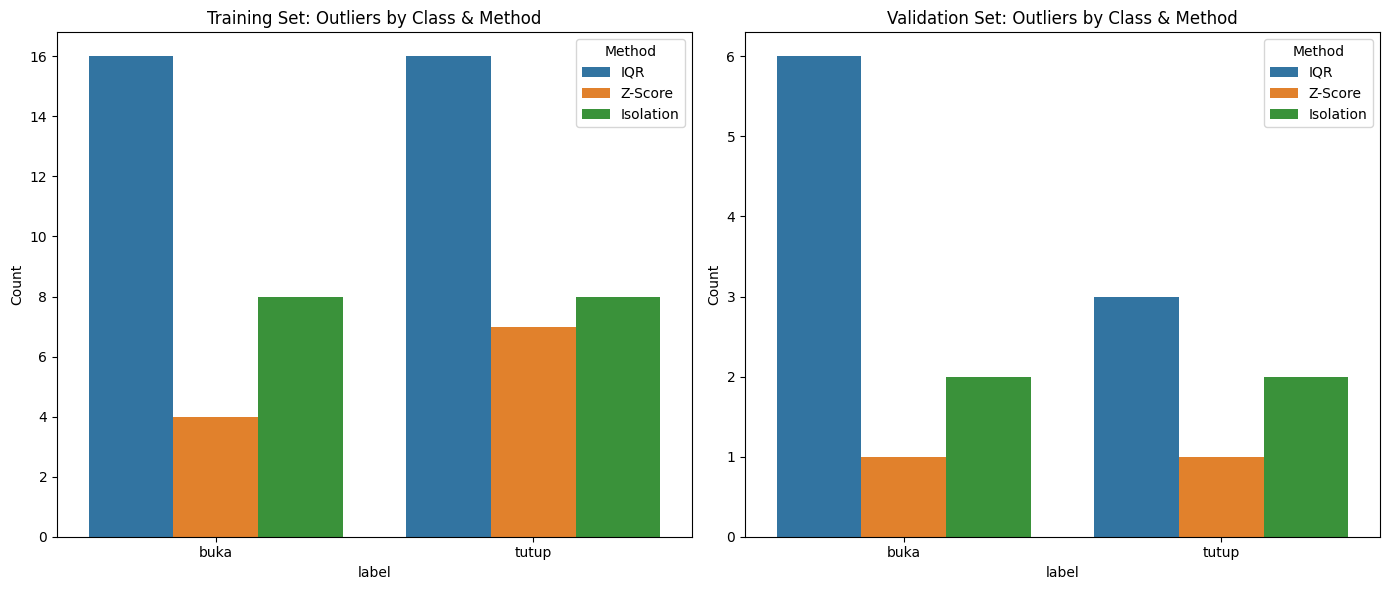

Outlier removal dengan consensus:
  Original samples: 160
  Outliers removed: 15 (9.4%)
  Clean samples: 145 (90.6%)

Distribusi kelas:
  Original: {'buka': 80, 'tutup': 80}
  Clean: {'buka': 76, 'tutup': 69}
  Removed: {'tutup': 11, 'buka': 4}
Outlier removal dengan consensus:
  Original samples: 40
  Outliers removed: 6 (15.0%)
  Clean samples: 34 (85.0%)

Distribusi kelas:
  Original: {'buka': 20, 'tutup': 20}
  Clean: {'buka': 17, 'tutup': 17}
  Removed: {'tutup': 3, 'buka': 3}

Dataset clean disimpan:
   train_features_clean.csv: (145, 6)
   val_features_clean.csv: (34, 6)
   train_outliers_removed.csv: (15, 6)
   val_outliers_removed.csv: (6, 6)


In [52]:
train_outliers, val_outliers = analyze_outliers(train_selected, val_selected, contamination=0.1)

# Hapus outlier dengan consensus
train_clean, train_removed = remove_outliers_consensus(train_selected, train_outliers, min_methods=2)
val_clean, val_removed = remove_outliers_consensus(val_selected, val_outliers, min_methods=2)

# Simpan dataset clean
train_clean.to_csv("train_features_clean.csv", index=False)
val_clean.to_csv("val_features_clean.csv", index=False)
train_removed.to_csv("train_outliers_removed.csv", index=False)
val_removed.to_csv("val_outliers_removed.csv", index=False)

print(f"\nDataset clean disimpan:")
print(f"   train_features_clean.csv: {train_clean.shape}")
print(f"   val_features_clean.csv: {val_clean.shape}")
print(f"   train_outliers_removed.csv: {train_removed.shape}")
print(f"   val_outliers_removed.csv: {val_removed.shape}")